# Fashion MNIST – Klassificering av klädesplagg

## Sammanfattning
I det här projektet har vi byggt en klassificeringsmodell som identifierar 
klädesplagg från Fashion MNIST-datasetet. Modellen tar en 28x28 gråskalebild 
som input och förutsäger vilken av 10 klasser den tillhör.

Vårt fokusområde är **optimering och learning rate**. Vi har undersökt hur 
valet av optimerare påverkar hur snabbt och stabilt modellen lär sig.

## Vad vi testade
Vi tränade samma modellarkitektur med fem olika optimerare:
- SGD (låg learning rate: 0.001)
- SGD (learning rate: 0.01)
- SGD + Momentum (learning rate: 0.01, momentum: 0.9)
- Adam (learning rate: 0.001)
- AdamW (learning rate: 0.001, weight decay: 0.01)

## Resultat
| Optimizer | Test Accuracy |
|-----------|--------------|
| Adam | 87.33% |
| AdamW | 87.25% |
| SGD + Momentum | 87.15% |
| SGD | 85.42% |
| SGD (låg lr) | 79.79% |

Adam och AdamW presterade bäst över 10 epoker, följda av SGD med momentum. 
Vi noterar dock att SGD fortfarande förbättrades vid 10 epoker och därför 
skulle kunna prestera bättre om fler epoker användes.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

## Modellarkitektur

Vi byggde ett fully connected neuralt nätverk (Dense layers) med följande struktur:

| Lager | Detaljer |
|-------|----------|
| Input | 28x28 pixlar (gråskala) |
| Flatten | Omformar bilden till en vektor av 784 värden |
| Dense | 128 neuroner, ReLU-aktivering |
| Dropout | 20% av neuroner stängs av slumpmässigt under träning |
| Dense | 10 neuroner, Softmax-aktivering (en per klass) |

### Våra val
**128 neuroner** i det dolda lagret är en balans mellan kapacitet och 
komplexitet – tillräckligt stort för att lära sig mönster i datan utan 
att bli onödigt tungt att träna.

**Dropout(0.2)** används för att minska risken för overfitting. Under 
träning stängs 20% av neuronerna av slumpmässigt, vilket tvingar nätverket 
att inte förlita sig för mycket på enskilda neuroner.

**Softmax** i outputlagret omvandlar nätverkets råa värden till 
sannolikheter för varje klass. Den klass med högst sannolikhet blir 
modellens förutsägelse.

### Dataförberedelse
Bildernas pixelvärden normaliserades från [0, 255] till [0, 1] genom 
att dividera med 255. Detta gör att träningen blir mer stabil eftersom 
nätverket hanterar små tal bättre än stora.

In [2]:
#Load dataseet

fashion_mnist = tf.keras.datasets.fashion_mnist

# Train och test uppdelning är redan hårdkodad av Zalando
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()



In [3]:
print(train_images.shape)
print(test_images.shape)

print(train_labels)


(60000, 28, 28)
(10000, 28, 28)
[9 0 0 ... 3 0 5]


In [4]:
# Klassnamn från https://github.com/zalandoresearch/fashion-mnist
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [5]:
# Normalisera pixelvärden från [0, 255] till [0, 1]
train_images = train_images / 255.0

test_images = test_images / 255.0

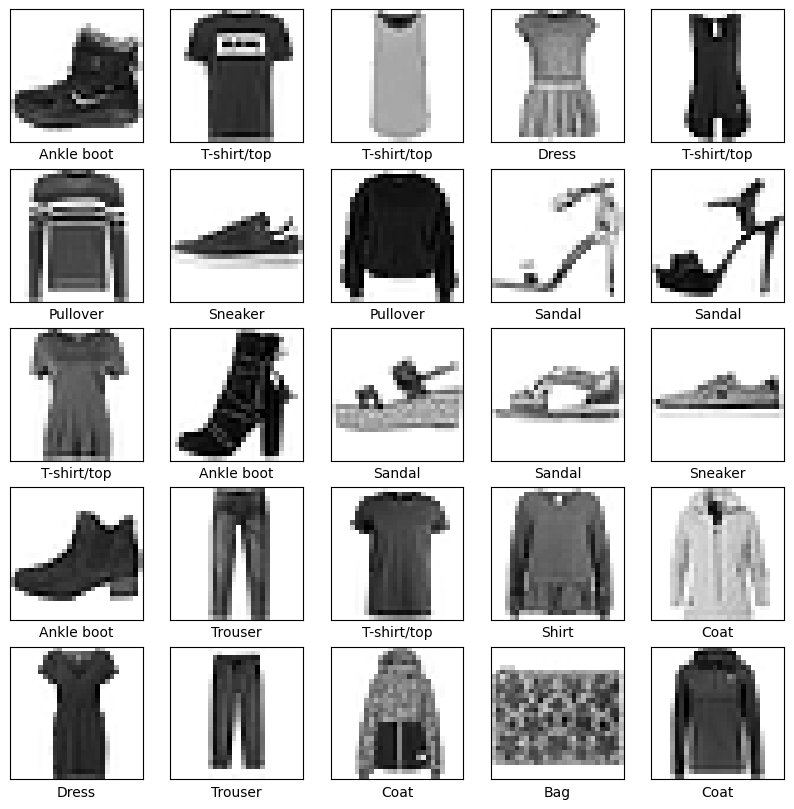

In [6]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [27]:
# Build neural network
# Keras default är batch size = 32

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),      # Valde 128 neuroner för att det är en vanlig storlek 
    Dropout(0.2),
    Dense(10, activation='softmax')     
])


In [8]:
# Compile Model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## Träning och validering

Alla modeller tränades med följande inställningar:
- 10 epochs
- Batch size: 32
- Validation split: 0.2 (20% av träningsdatan används för validering)

Det innebär att modellen i praktiken tränas på 48 000 bilder och 
valideras på 12 000 bilder per epoch. De 10 000 testbilderna används 
endast för den slutliga utvärderingen.

Observation: hoppig valideringskurva
Vid träning med Adam noterade vi att valideringskurvan studsade lite 
upp och ner mellan epochs, medan träningskurvan sjönk stadigt.

Detta är normalt och beror på två saker:
- Valideringsdatan är mindre (12 000 bilder) vilket gör kurvan känsligare 
  för slumpvariationer
- Dropout är aktiv under träning men avstängd vid validering, vilket 
  introducerar lite variation från epoch till epoch

In [17]:
# Train Model

history = model.fit(
    train_images,
    train_labels,
    epochs=10,              # Istället för att välja 10 epochs så kan vi kolla vilket nummer som är optimalt
    
    validation_split=0.2
)



Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 693us/step - accuracy: 0.8963 - loss: 0.2798 - val_accuracy: 0.8837 - val_loss: 0.3237
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 649us/step - accuracy: 0.8990 - loss: 0.2721 - val_accuracy: 0.8870 - val_loss: 0.3134
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 769us/step - accuracy: 0.8996 - loss: 0.2683 - val_accuracy: 0.8819 - val_loss: 0.3315
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 628us/step - accuracy: 0.9015 - loss: 0.2612 - val_accuracy: 0.8904 - val_loss: 0.3165
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 735us/step - accuracy: 0.9040 - loss: 0.2564 - val_accuracy: 0.8836 - val_loss: 0.3278
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 614us/step - accuracy: 0.9028 - loss: 0.2549 - val_accuracy: 0.8862 - val_loss: 0.3253
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step - accuracy: 0.9064 - loss: 0.2470 - val_accuracy: 0.8898 - val_loss: 0.3148
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 641us/step - accuracy: 0.9084 -

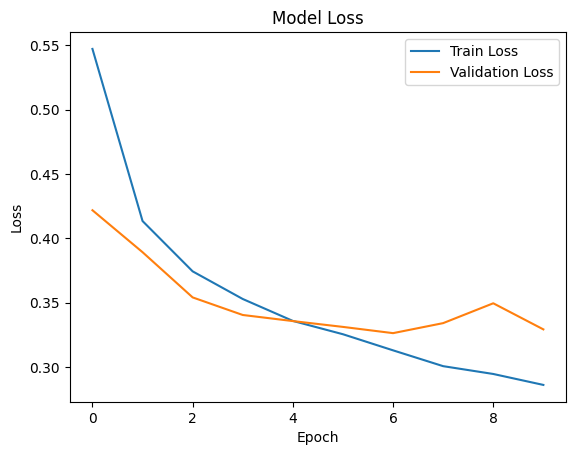

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()


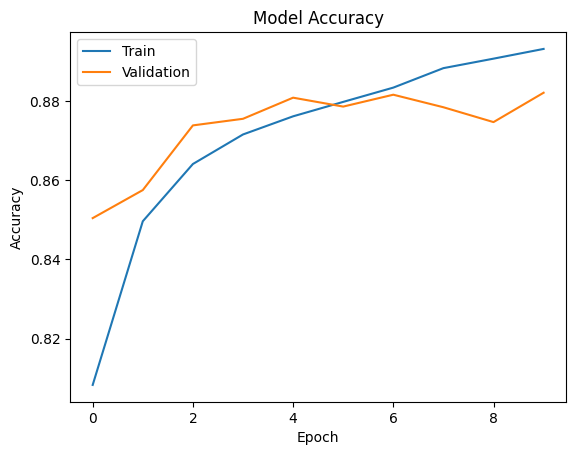

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()


In [12]:
# Validation 

test_loss, test_acc = model.evaluate(
    test_images,
    test_labels
)

print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step - accuracy: 0.8733 - loss: 0.3591
Test accuracy: 0.8733000159263611


## Analys av optimerare

Vi tränade samma modell fem gånger med olika optimerare för att kunna 
göra en rättvis jämförelse. Enda skillnaden mellan körningarna var 
valet av optimerare – arkitektur, antal epochs och batch size var identiska.

### SGD – Stochastic Gradient Descent
Vanlig SGD med learning rate 0.01 startade på 71.6% accuracy vid epoch 1 
och förbättrades stadigt till 85.4% vid epoch 10. Kurvan var jämn men 
långsam. Modellen var tydligt inte klar vid epoch 10 och hade förmodligen 
fortsatt förbättras med fler epochs.

### SGD med låg learning rate
Med learning rate 0.001 startade modellen på bara 51.8%, knappt bättre 
än slumpmässig gissning. Det här är det tydligaste exemplet på vad för
låg learning rate innebär i praktiken: modellen lär sig långsamt och
hinner inte konvergera på 10 epoker.

### SGD + Momentum
Momentum (0.9) gjorde en stor skillnad, Epoch 1 landade på 79.2% jämfört 
med SGDs 71.6%. Momentum fungerar som en boll som rullar nerför en backe: 
den accelererar i rätt riktning istället för att ta ett litet steg i taget. 
Slutresultatet (87.2%) var nästan identiskt med Adam.

### Adam
Adam kom igång snabbt (89.6% redan vid epoch 1) men planade ut tidigt. 
Valideringskurvan förbättrades knappt efter epoch 4. Det beror på att 
Adam automatiskt anpassar learning rate per parameter och bromsar in när 
den hittar ett bra område. Den "blev klar" betydligt tidigare än SGD.

### AdamW
AdamW är en förbättrad version av Adam som separerar weight decay från 
gradientuppdateringen korrekt. Resultatet (87.25%) var nästan identiskt 
med Adam på detta dataset. AdamWs fördel syns tydligare på större modeller 
och mer komplex data. 

### Slutsats
Adam och AdamW presterade bäst på kort sikt tack vare snabb konvergens. 
SGD med momentum kom nära samma slutresultat men behövde mer epochs för 
att komma dit. 

In [13]:
# Testar med SGD optimizer

# Skapa en Ny modell (viktigt för rätt jämförelse)
model_sgd = Sequential([
    Input(shape=(28, 28)),     # Input = 28x28 bild
    Flatten(),                 # Gör om bilden till en vektor
    Dense(128, activation='relu'),  # Dold lager
    Dropout(0.2),             # Regularisering (minskar overfitting)
    Dense(10, activation='softmax') # Output (10 klasser)
])

# SGD optimizer (utan momentum)
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01
)

# Kompilera modellen
model_sgd.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Träna modellen
history_sgd = model_sgd.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

# Utvärdera på testdata
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(test_images, test_labels)

print("SGD Test accuracy:", test_acc_sgd)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 506us/step - accuracy: 0.7160 - loss: 0.8593 - val_accuracy: 0.8039 - val_loss: 0.5896
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step - accuracy: 0.8020 - loss: 0.5886 - val_accuracy: 0.8218 - val_loss: 0.5179
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 428us/step - accuracy: 0.8208 - loss: 0.5271 - val_accuracy: 0.8328 - val_loss: 0.4816
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 422us/step - accuracy: 0.8310 - loss: 0.4913 - val_accuracy: 0.8360 - val_loss: 0.4636
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 458us/step - accuracy: 0.8393 - loss: 0.4668 - val_accuracy: 0.8447 - val_loss: 0.4412
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 422us/step - accuracy: 0.8452 - loss: 0.4496 - val_accuracy: 0.8463 - val_loss: 0.4328
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 419us/step - accuracy: 0.8490 - loss: 0.4343 - val_accuracy: 0.8497 - val_loss: 0.4269
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 418us/step - accuracy: 0.8543 -

In [14]:
model_sgd_low = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.001
)

model_sgd_low.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd_low = model_sgd_low.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_sgd_low, test_acc_sgd_low = model_sgd_low.evaluate(test_images, test_labels)

print("SGD (low LR) Test accuracy:", test_acc_sgd_low)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 472us/step - accuracy: 0.5181 - loss: 1.5563 - val_accuracy: 0.6898 - val_loss: 1.1080
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 425us/step - accuracy: 0.6696 - loss: 1.0380 - val_accuracy: 0.7392 - val_loss: 0.8731
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 424us/step - accuracy: 0.7080 - loss: 0.8910 - val_accuracy: 0.7565 - val_loss: 0.7770
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 421us/step - accuracy: 0.7336 - loss: 0.8111 - val_accuracy: 0.7744 - val_loss: 0.7201
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 422us/step - accuracy: 0.7507 - loss: 0.7604 - val_accuracy: 0.7800 - val_loss: 0.6821
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 425us/step - accuracy: 0.7611 - loss: 0.7265 - val_accuracy: 0.7868 - val_loss: 0.6535
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 443us/step - accuracy: 0.7685 - loss: 0.6952 - val_accuracy: 0.7929 - val_loss: 0.6302
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 451us/step - accuracy: 0.7770 -

In [15]:
model_sgd_m = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

model_sgd_m.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd_m = model_sgd_m.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_sgd_m, test_acc_sgd_m = model_sgd_m.evaluate(test_images, test_labels)

print("SGD + Momentum Test accuracy:", test_acc_sgd_m)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.7918 - loss: 0.5878 - val_accuracy: 0.8392 - val_loss: 0.4403
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 700us/step - accuracy: 0.8428 - loss: 0.4394 - val_accuracy: 0.8594 - val_loss: 0.3930
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 438us/step - accuracy: 0.8546 - loss: 0.3996 - val_accuracy: 0.8603 - val_loss: 0.3844
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 440us/step - accuracy: 0.8627 - loss: 0.3778 - val_accuracy: 0.8730 - val_loss: 0.3521
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 443us/step - accuracy: 0.8671 - loss: 0.3633 - val_accuracy: 0.8724 - val_loss: 0.3492
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 439us/step - accuracy: 0.8722 - loss: 0.3470 - val_accuracy: 0.8751 - val_loss: 0.3414
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 437us/step - accuracy: 0.8779 - loss: 0.3353 - val_accuracy: 0.8662 - val_loss: 0.3526
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 437us/step - accuracy: 0.8793 -

In [18]:
# Prövar AdamW med learning rate 0.001 och weight decay 0.01

model_adamw = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.01
)

model_adamw.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adamw = model_adamw.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_adamw, test_acc_adamw = model_adamw.evaluate(test_images, test_labels)

print("AdamW Test accuracy:", test_acc_adamw)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 653us/step - accuracy: 0.8052 - loss: 0.5536 - val_accuracy: 0.8462 - val_loss: 0.4172
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 602us/step - accuracy: 0.8522 - loss: 0.4100 - val_accuracy: 0.8541 - val_loss: 0.3982
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 576us/step - accuracy: 0.8636 - loss: 0.3742 - val_accuracy: 0.8626 - val_loss: 0.3689
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 645us/step - accuracy: 0.8707 - loss: 0.3515 - val_accuracy: 0.8758 - val_loss: 0.3486
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - accuracy: 0.8750 - loss: 0.3388 - val_accuracy: 0.8804 - val_loss: 0.3282
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 655us/step - accuracy: 0.8815 - loss: 0.3210 - val_accuracy: 0.8764 - val_loss: 0.3450
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 623us/step - accuracy: 0.8835 - loss: 0.3149 - val_accuracy: 0.8857 - val_loss: 0.3230
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.8859 -

In [19]:
# Jämförelse av alla modeller

print("Adam:", test_acc)
print("SGD:", test_acc_sgd)
print("SGD (low LR):", test_acc_sgd_low)
print("SGD + Momentum:", test_acc_sgd_m)
print("AdamW:", test_acc_adamw)


Adam: 0.8733000159263611
SGD: 0.854200005531311
SGD (low LR): 0.7979000210762024
SGD + Momentum: 0.8715000152587891
AdamW: 0.8725000023841858


In [26]:
results = pd.DataFrame({
    'Optimizer': ['Adam', 'AdamW', 'SGD + Momentum', 'SGD', 'SGD (låg lr)'],
    'Learning Rate': [0.001, 0.001, 0.01, 0.01, 0.001],
    'Weight Decay': ['-', '0.01', '-', '-', '-'],
    'Test Accuracy': [test_acc, test_acc_adamw, test_acc_sgd_m, test_acc_sgd, test_acc_sgd_low]
})

results['Test Accuracy'] = results['Test Accuracy'].map('{:.2%}'.format)
results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))
print("\nAlla modeller tränade med 10 epochs och Keras default batch size 32")

     Optimizer  Learning Rate Weight Decay Test Accuracy
          Adam          0.001            -        87.33%
         AdamW          0.001         0.01        87.25%
SGD + Momentum          0.010            -        87.15%
           SGD          0.010            -        85.42%
  SGD (låg lr)          0.001            -        79.79%

Alla modeller tränade med 10 epochs och Keras default batch size 32


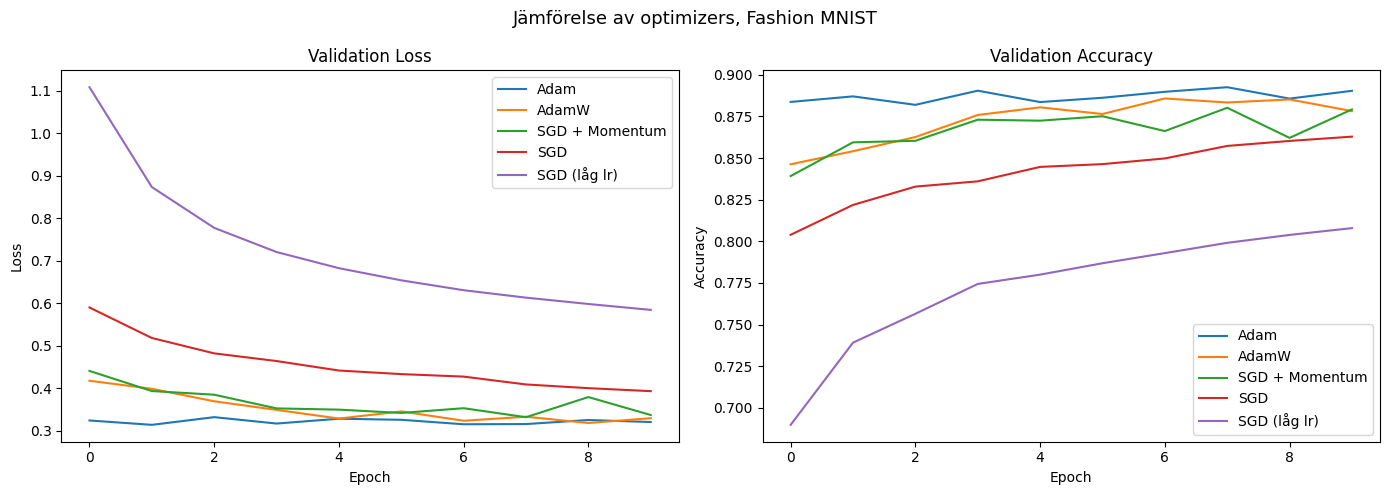

In [21]:
# Träningskurvor för alla optimisers

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['val_loss'], label='Adam')
ax1.plot(history_adamw.history['val_loss'], label='AdamW')
ax1.plot(history_sgd_m.history['val_loss'], label='SGD + Momentum')
ax1.plot(history_sgd.history['val_loss'], label='SGD')
ax1.plot(history_sgd_low.history['val_loss'], label='SGD (låg lr)')
ax1.set_title('Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy
ax2.plot(history.history['val_accuracy'], label='Adam')
ax2.plot(history_adamw.history['val_accuracy'], label='AdamW')
ax2.plot(history_sgd_m.history['val_accuracy'], label='SGD + Momentum')
ax2.plot(history_sgd.history['val_accuracy'], label='SGD')
ax2.plot(history_sgd_low.history['val_accuracy'], label='SGD (låg lr)')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Jämförelse av optimizers, Fashion MNIST', fontsize=13)
plt.tight_layout()
plt.show()